[INFO] Charts will be saved to: ./charts/
[INFO] Jupyter detected: True

───────────────────────────────────────────────────────
  Chart 01 — Monthly Revenue Trend
───────────────────────────────────────────────────────
[OK]   Saved → charts/01_monthly_revenue_trend.png


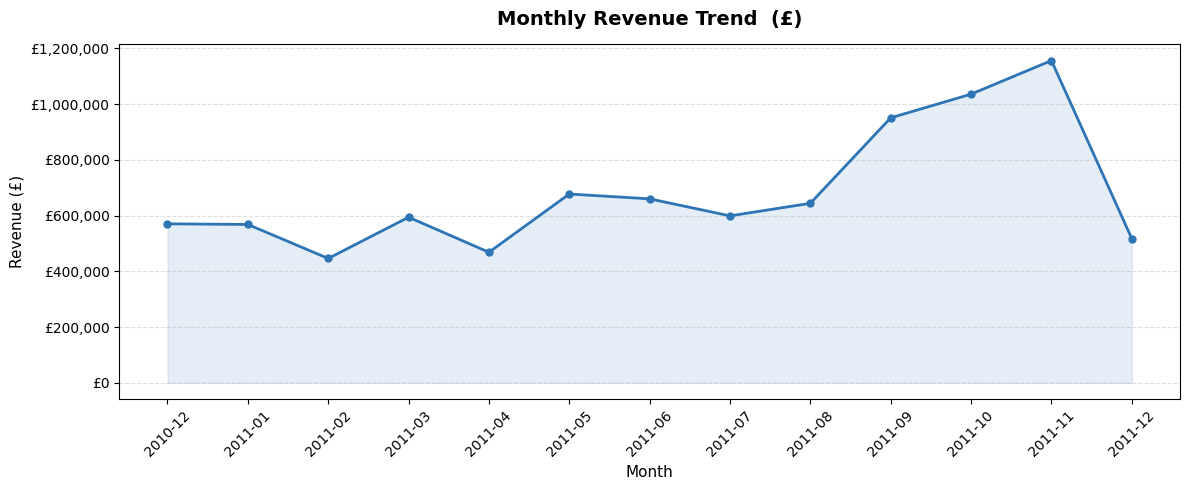


───────────────────────────────────────────────────────
  Chart 02 — Top 10 Customers by Revenue
───────────────────────────────────────────────────────
[OK]   Saved → charts/02_top10_customers_revenue.png


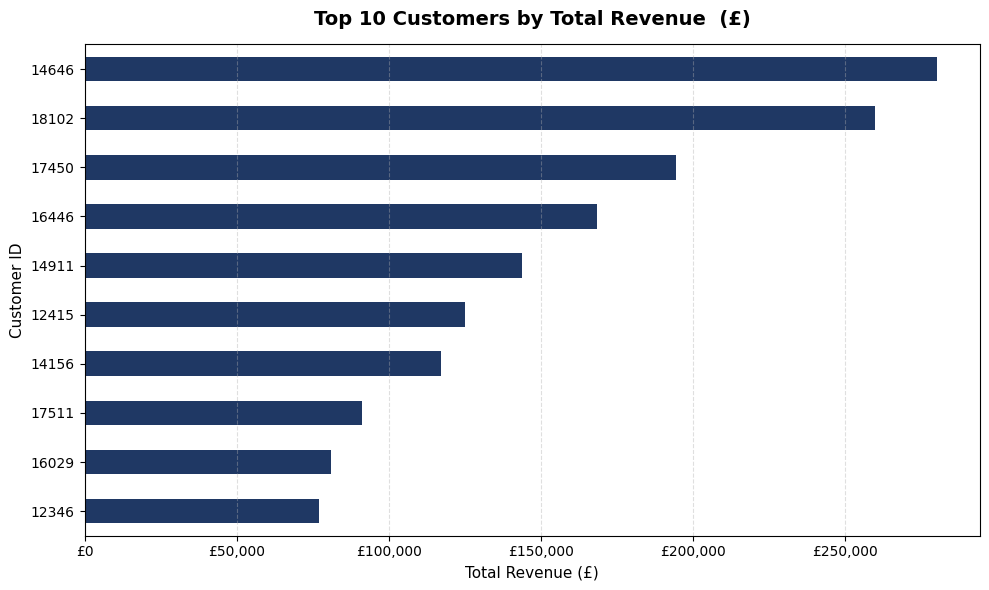


───────────────────────────────────────────────────────
  Chart 03 — Top 10 Products by Revenue
───────────────────────────────────────────────────────
[OK]   Saved → charts/03_top10_products_revenue.png


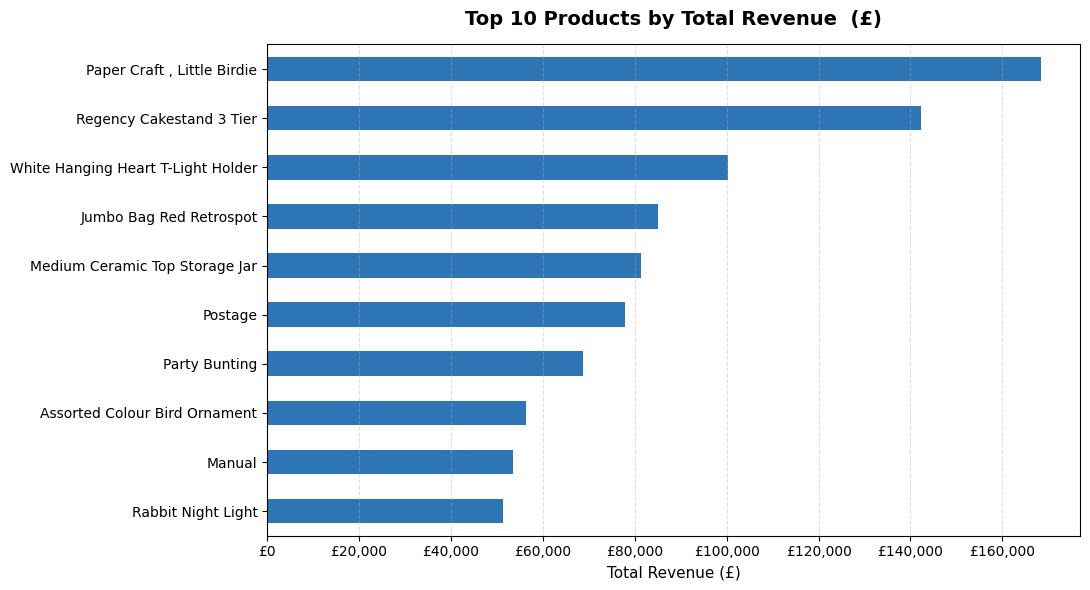


───────────────────────────────────────────────────────
  Chart 04 — Revenue by Country  (Top 10)
───────────────────────────────────────────────────────
[OK]   Saved → charts/04_revenue_by_country.png


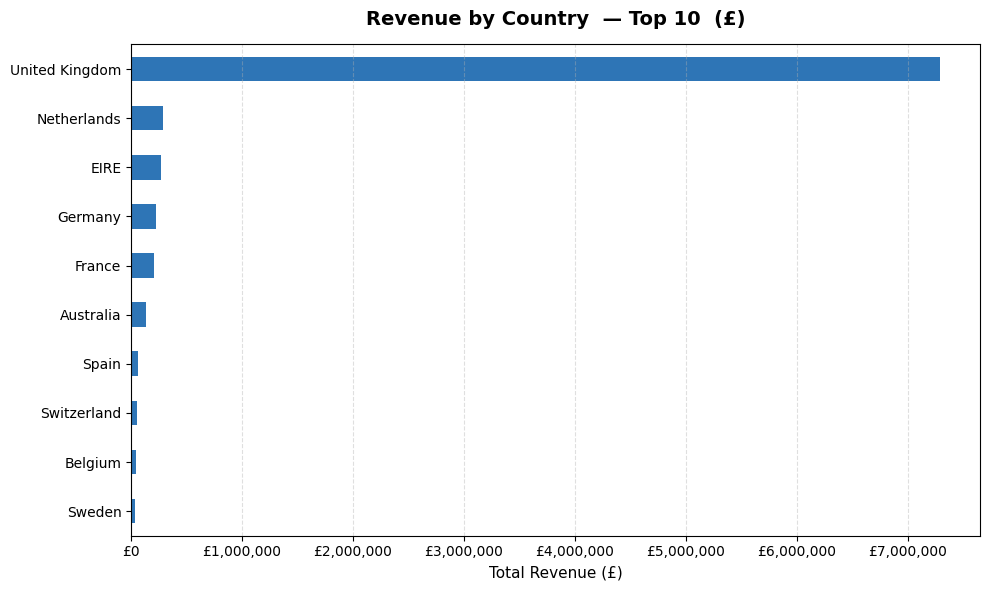


───────────────────────────────────────────────────────
  Chart 05 — Transactions by Day of Week
───────────────────────────────────────────────────────
[OK]   Saved → charts/05_transactions_by_dow.png


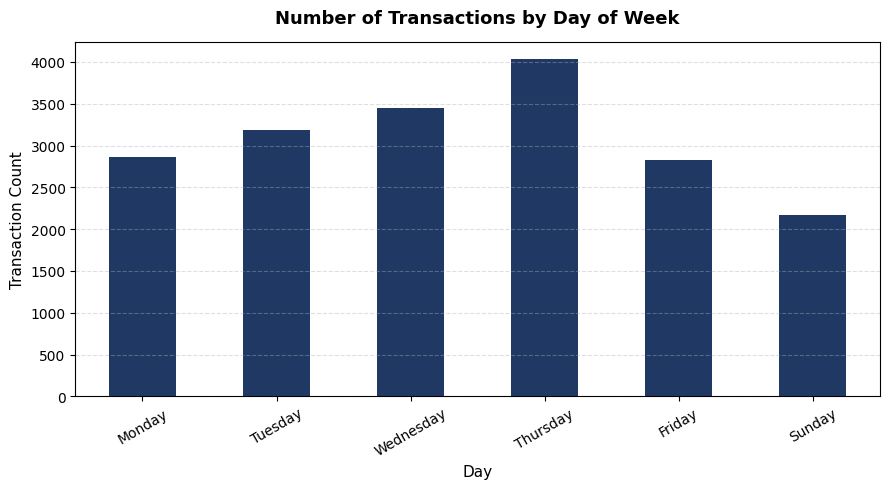


  All 5 charts saved to ./charts/
  Open in Jupyter or any image viewer.



In [3]:
"""
04_visualise.py
===============
Connects to MySQL, runs analytical SQL queries, pulls results into
Pandas DataFrames, and generates all charts using Pandas .plot()
(matplotlib backend).

Charts produced:
  01 — Monthly Revenue Trend             (line chart)
  02 — Top 10 Customers by Revenue       (horizontal bar)
  03 — Top 10 Products by Revenue        (horizontal bar)
  04 — Revenue by Country (Top 10)       (horizontal bar)
  05 — Transactions by Day of Week       (bar chart)

All charts are saved as PNG files in the /charts directory.
When run inside a Jupyter notebook the charts are also rendered inline.

Usage:
    python 04_visualise.py          # script mode  — saves only
    # or open in Jupyter            # notebook mode — saves + shows inline
"""

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sqlalchemy import create_engine, text

warnings.filterwarnings("ignore")


# ── Detect Jupyter ─────────────────────────────────────────────────────────────
def is_jupyter() -> bool:
    """Return True when running inside a Jupyter kernel."""
    try:
        shell = get_ipython().__class__.__name__          # noqa: F821
        return shell in ("ZMQInteractiveShell",           # Jupyter notebook/lab
                         "TerminalInteractiveShell")      # ipython terminal
    except NameError:
        return False                                       # plain Python script


# Activate inline display only when inside Jupyter
if is_jupyter():
    from IPython import get_ipython
    get_ipython().run_line_magic("matplotlib", "inline")
else:
    import matplotlib
    matplotlib.use("Agg")                                  # safe non-interactive backend


# ── Configuration ─────────────────────────────────────────────────────────────
DB_HOST    = "localhost"
DB_PORT    = 3306
DB_NAME    = "online_retail"
DB_USER    = "root"
DB_PASS    = "secret"
TABLE_NAME = "online_retail_clean"

CHARTS_DIR = "charts"

# Colour palette
C_NAVY   = "#1F3864"
C_BLUE   = "#2E75B6"
C_LBLUE  = "#BDD7EE"
C_ACCENT = "#E67E22"


# ── Helpers ───────────────────────────────────────────────────────────────────
def banner(title: str):
    print(f"\n{'─'*55}")
    print(f"  {title}")
    print(f"{'─'*55}")


def save_and_show(fig, filename: str):
    """Save the figure to disk, then display it if inside Jupyter."""
    path = os.path.join(CHARTS_DIR, filename)
    fig.savefig(path, dpi=150, bbox_inches="tight")
    print(f"[OK]   Saved → {path}")

    if is_jupyter():
        plt.show()          # renders inline in the notebook cell output
    else:
        plt.close(fig)      # free memory in script mode


def engine_connect():
    connection_string = (
        f"mysql+mysqlconnector://{DB_USER}:{DB_PASS}"
        f"@{DB_HOST}:{DB_PORT}/{DB_NAME}"
    )
    return create_engine(connection_string, echo=False)


def run_query(engine, sql: str) -> pd.DataFrame:
    with engine.connect() as conn:
        return pd.read_sql(text(sql), conn)


# ── Chart 01: Monthly Revenue Trend ──────────────────────────────────────────
def chart_monthly_revenue(engine):
    banner("Chart 01 — Monthly Revenue Trend")
    sql = f"""
        SELECT
            CONCAT(Year, '-', LPAD(Month, 2, '0')) AS YearMonth,
            ROUND(SUM(TotalLineValue), 2)           AS Revenue
        FROM {TABLE_NAME}
        GROUP BY Year, Month
        ORDER BY Year, Month
    """
    df = run_query(engine, sql)
    df["Revenue"] = df["Revenue"].astype(float)

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(df["YearMonth"], df["Revenue"], color=C_BLUE, marker="o", linewidth=2, markersize=5)
    ax.fill_between(df["YearMonth"], df["Revenue"], alpha=0.12, color=C_BLUE)
    ax.set_title("Monthly Revenue Trend  (£)", fontsize=14, fontweight="bold", pad=14)
    ax.set_xlabel("Month", fontsize=11)
    ax.set_ylabel("Revenue (£)", fontsize=11)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}"))
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    fig.tight_layout()
    save_and_show(fig, "01_monthly_revenue_trend.png")


# ── Chart 02: Top 10 Customers by Revenue ────────────────────────────────────
def chart_top_customers(engine):
    banner("Chart 02 — Top 10 Customers by Revenue")
    sql = f"""
        SELECT
            CustomerID,
            ROUND(SUM(TotalLineValue), 2) AS TotalRevenue
        FROM {TABLE_NAME}
        GROUP BY CustomerID
        ORDER BY TotalRevenue DESC
        LIMIT 10
    """
    df = run_query(engine, sql)
    df["TotalRevenue"] = df["TotalRevenue"].astype(float)
    df = df.sort_values("TotalRevenue")

    fig, ax = plt.subplots(figsize=(10, 6))
    df.plot.barh(x="CustomerID", y="TotalRevenue", ax=ax, color=C_NAVY, legend=False)
    ax.set_title("Top 10 Customers by Total Revenue  (£)", fontsize=14, fontweight="bold", pad=14)
    ax.set_xlabel("Total Revenue (£)", fontsize=11)
    ax.set_ylabel("Customer ID", fontsize=11)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}"))
    ax.grid(axis="x", linestyle="--", alpha=0.4)
    fig.tight_layout()
    save_and_show(fig, "02_top10_customers_revenue.png")


# ── Chart 03: Top 10 Products by Revenue ─────────────────────────────────────
def chart_top_products(engine):
    banner("Chart 03 — Top 10 Products by Revenue")
    sql = f"""
        SELECT
            Description,
            ROUND(SUM(TotalLineValue), 2) AS TotalRevenue
        FROM {TABLE_NAME}
        GROUP BY Description
        ORDER BY TotalRevenue DESC
        LIMIT 10
    """
    df = run_query(engine, sql)
    df["TotalRevenue"] = df["TotalRevenue"].astype(float)
    df["Description"] = df["Description"].str[:40]   # truncate long names
    df = df.sort_values("TotalRevenue")

    fig, ax = plt.subplots(figsize=(11, 6))
    df.plot.barh(x="Description", y="TotalRevenue", ax=ax, color=C_BLUE, legend=False)
    ax.set_title("Top 10 Products by Total Revenue  (£)", fontsize=14, fontweight="bold", pad=14)
    ax.set_xlabel("Total Revenue (£)", fontsize=11)
    ax.set_ylabel("")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}"))
    ax.grid(axis="x", linestyle="--", alpha=0.4)
    fig.tight_layout()
    save_and_show(fig, "03_top10_products_revenue.png")


# ── Chart 04: Revenue by Country (Top 10) ────────────────────────────────────
def chart_country_revenue(engine):
    banner("Chart 04 — Revenue by Country  (Top 10)")
    sql = f"""
        SELECT
            Country,
            ROUND(SUM(TotalLineValue), 2) AS Revenue
        FROM {TABLE_NAME}
        GROUP BY Country
        ORDER BY Revenue DESC
        LIMIT 10
    """
    df = run_query(engine, sql)
    df["Revenue"] = df["Revenue"].astype(float)
    df = df.sort_values("Revenue")

    fig, ax = plt.subplots(figsize=(10, 6))
    df.plot.barh(x="Country", y="Revenue", ax=ax, color=C_BLUE, legend=False)
    ax.set_title("Revenue by Country  — Top 10  (£)", fontsize=14, fontweight="bold", pad=14)
    ax.set_xlabel("Total Revenue (£)", fontsize=11)
    ax.set_ylabel("")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}"))
    ax.grid(axis="x", linestyle="--", alpha=0.4)
    fig.tight_layout()
    save_and_show(fig, "04_revenue_by_country.png")


# ── Chart 05: Transactions by Day of Week ────────────────────────────────────
def chart_dow(engine):
    banner("Chart 05 — Transactions by Day of Week")
    sql = f"""
        SELECT
            DayOfWeek,
            COUNT(DISTINCT InvoiceNo) AS Transactions
        FROM {TABLE_NAME}
        GROUP BY DayOfWeek
    """
    df = run_query(engine, sql)
    day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
    df["DayOfWeek"] = pd.Categorical(df["DayOfWeek"], categories=day_order, ordered=True)
    df = df.sort_values("DayOfWeek")

    fig, ax = plt.subplots(figsize=(9, 5))
    df.plot.bar(x="DayOfWeek", y="Transactions", ax=ax, color=C_NAVY, legend=False)
    ax.set_title("Number of Transactions by Day of Week", fontsize=13, fontweight="bold", pad=14)
    ax.set_xlabel("Day", fontsize=11)
    ax.set_ylabel("Transaction Count", fontsize=11)
    ax.tick_params(axis="x", rotation=30)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    fig.tight_layout()
    save_and_show(fig, "05_transactions_by_dow.png")


# ── Main ──────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    os.makedirs(CHARTS_DIR, exist_ok=True)
    print(f"[INFO] Charts will be saved to: ./{CHARTS_DIR}/")
    print(f"[INFO] Jupyter detected: {is_jupyter()}")

    engine = engine_connect()

    chart_monthly_revenue(engine)
    chart_top_customers(engine)
    chart_top_products(engine)
    chart_country_revenue(engine)
    chart_dow(engine)

    print(f"\n{'='*55}")
    print(f"  All 5 charts saved to ./{CHARTS_DIR}/")
    print(f"  Open in Jupyter or any image viewer.")
    print(f"{'='*55}\n")